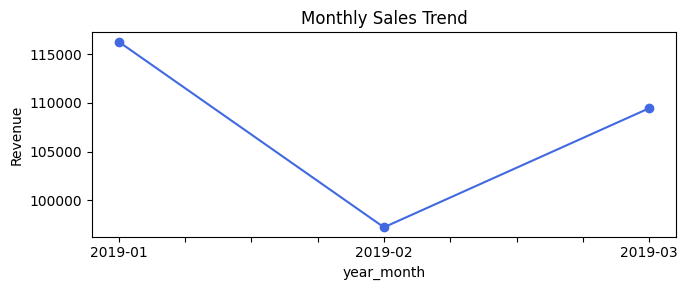

Accuracy: 0.46
Recall: 0.2727272727272727
Precision: 0.48

Confusion Matrix:
 [[79 39]
 [96 36]]


In [3]:
# ============================================================
# IBM SkillsBuild x BharatCares x AICTE Internship Project
# Supermarket Sales Analytics & Customer Churn Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score

# 1. LOAD DATASET
raw_url = "https://raw.githubusercontent.com/selva86/datasets/master/supermarket_sales.csv"
df = pd.read_csv(raw_url)

# 2. DATA PREPROCESSING & HYGIENE
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
date_col = [c for c in df.columns if 'date' in c][0]
df[date_col] = pd.to_datetime(df[date_col])

if 'quantity' in df.columns:
    df['quantity'] = df['quantity'].abs()

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 3. EXPLORATORY DATA ANALYSIS (EDA)
rev_col = [c for c in df.columns if 'total' in c or 'revenue' in c][0]
df['year_month'] = df[date_col].dt.to_period('M').astype(str)

# Monthly Trend
plt.figure(figsize=(7, 3))
df.groupby('year_month')[rev_col].sum().plot(kind='line', marker='o', color='royalblue')
plt.title('Monthly Sales Trend')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# 4. PREDICTIVE CHURN MODELING (RFM)
id_col = [c for c in df.columns if 'invoice' in c or 'customer' in c][0]
snapshot_date = df[date_col].max() + pd.Timedelta(days=1)

rfm = df.groupby(id_col).agg({
    date_col: lambda x: (snapshot_date - x.max()).days,
    id_col: 'count',
    rev_col: 'sum'
}).rename(columns={date_col: 'recency', id_col: 'frequency', rev_col: 'monetary'})

rfm['aov'] = rfm['monetary'] / rfm['frequency']
rfm['churn'] = (rfm['recency'] >= rfm['recency'].median()).astype(int)

# Train Test Split & Logistic Regression
X = rfm[['frequency', 'monetary', 'aov']]
y = rfm['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))